# M6 — Unsupervised Analysis: PCA & Clustering

Applies PCA for dimensionality reduction and KMeans clustering to explore whether natural patient groupings emerge from the features, then relates those groups back to the actual heart-disease target for interpretation.

## Load Cleaned Data

In [1]:
import pandas as pd

df = pd.read_csv("../data/heart_disease_clean.csv")
df["target_binary"] = (df["target"] > 0).astype(int)
df.shape

(303, 15)

## Preprocess Features

Missing `ca`/`thal` values are imputed (median/most-frequent) and all features are scaled, since both PCA and KMeans are distance-based and require comparable feature scales.

In [2]:
categorical_columns = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numeric_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]

X = df[numeric_columns + categorical_columns].copy()
y = df["target_binary"]

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_columns),
    ("cat", categorical_transformer, categorical_columns)
])

X_processed = preprocessor.fit_transform(X)
X_processed.shape

(303, 13)

## Dimensionality Reduction (PCA)

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components:", pca.explained_variance_ratio_.sum().round(3))

Explained variance ratio: [0.23687279 0.12307138]
Total variance captured by 2 components: 0.36


## Choosing the Number of Clusters (Elbow Method)

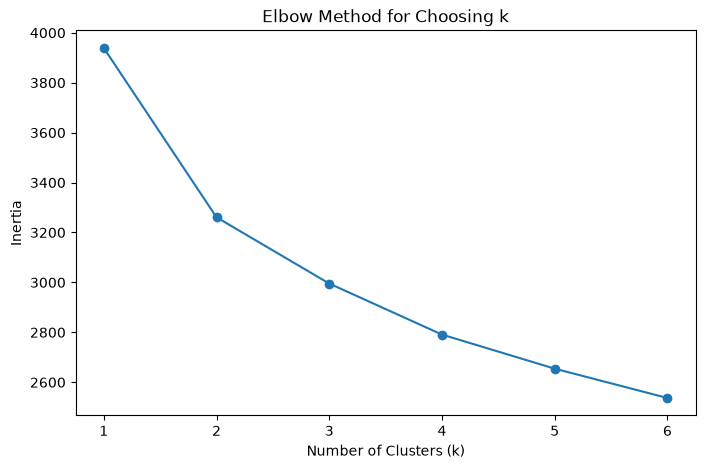

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_processed)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.title("Elbow Method for Choosing k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

The elbow flattens around **k = 2**, which also matches the binary (disease / no disease) nature of the target — so `k=2` is used below.

## Clustering (KMeans)

In [6]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_processed)

pd.Series(clusters).value_counts().sort_index()

0    114
1    189
Name: count, dtype: int64

## Visualization

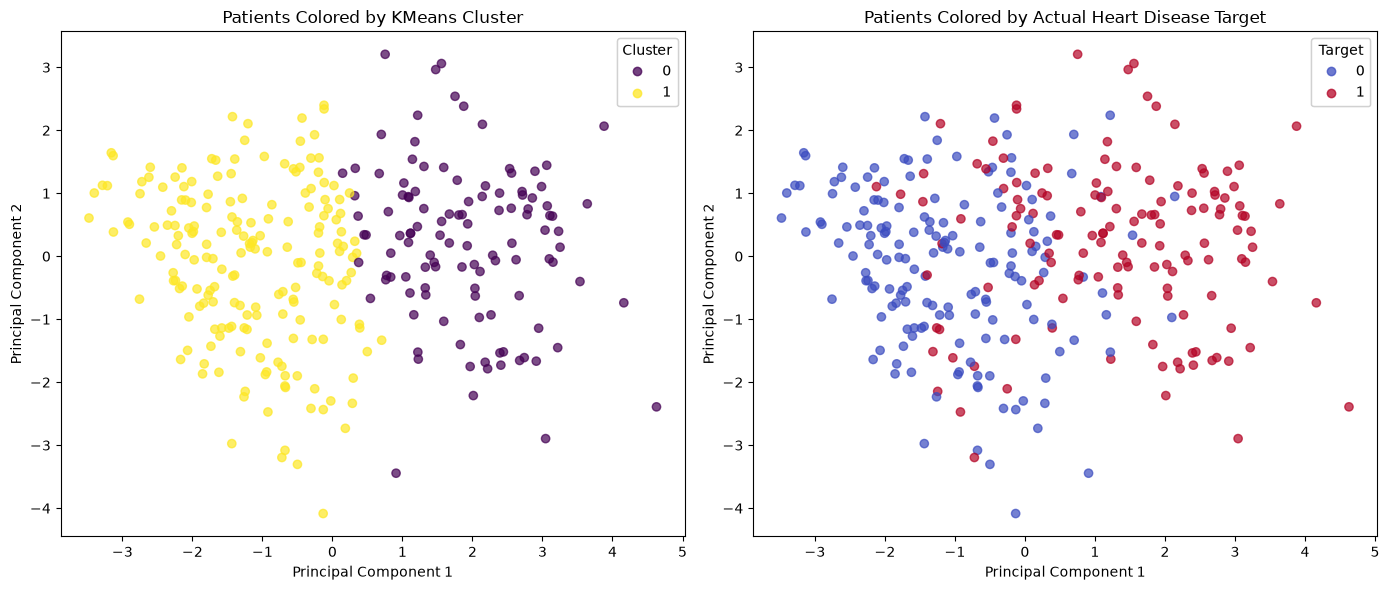

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", alpha=0.7)
axes[0].set_title("Patients Colored by KMeans Cluster")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
legend1 = axes[0].legend(*scatter1.legend_elements(), title="Cluster")
axes[0].add_artist(legend1)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.7)
axes[1].set_title("Patients Colored by Actual Heart Disease Target")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
legend2 = axes[1].legend(*scatter2.legend_elements(), title="Target")
axes[1].add_artist(legend2)

plt.tight_layout()

import os
os.makedirs("../outputs", exist_ok=True)

plt.savefig("../outputs/pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpretation: Clusters vs. Actual Diagnosis

In [8]:
comparison_table = pd.crosstab(
    pd.Series(clusters, name="KMeans Cluster"),
    pd.Series(y.values, name="Actual Target (0=no disease, 1=disease)")
)
comparison_table

"Actual Target (0=no disease, 1=disease)",0,1
KMeans Cluster,,
0,13,101
1,151,38


## M6 — Findings

- The first two principal components capture a substantial share of the total feature variance (see the explained variance ratio printed above), so the 2D PCA plot is a reasonable low-dimensional summary of each patient.
- The elbow plot supports splitting patients into **2 clusters**, matching the binary disease/no-disease structure of the target.
- The cross-tabulation shows how much the unsupervised clusters agree with the actual diagnosis label: if the clusters separate along roughly the same boundary as the true target, it suggests the underlying feature space naturally reflects disease status even without ever using the label to form the clusters.
- Where clusters and the true target disagree, those patients sit in a more ambiguous region of feature space — an interesting group for further clinical follow-up, though outside the scope of this project to diagnose.